# Faktorizacijski model za preporuku (Recommendation)

Cilj zadaće je implementirati faktorizacijski model za sistem preporuka.  
Koristi se **NMF (Non-negative Matrix Factorization)** nad matricom korisnik–knjiga iz **Book-Crossing** dataseta.  
Prikazuje se originalna rijetka (sparse) matrica, postupak faktorizacije,  
te rekonstruisana (popunjena) matrica na osnovu koje se generišu preporuke.


## Uvoz potrebnih biblioteka

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from sklearn.decomposition import NMF

np.random.seed(42)


## Učitavanje Book-Crossing dataseta

Koriste se fajlovi `Ratings.csv` i `Books.csv` koji sadrže ocjene korisnika za knjige (skala 1–10).  
Pošto je dataset velik (~1.1M ocjena), za prikaz uzimamo podskup:  
50 najaktivnijih korisnika i 50 najocjenjivanijih knjiga.


In [ ]:
df_raw   = pd.read_csv('Ratings.csv', sep=';', encoding='latin-1', on_bad_lines='skip')
df_books = pd.read_csv('Books.csv',   sep=';', encoding='latin-1', on_bad_lines='skip',
                       usecols=[0, 1, 2], dtype=str)

df_raw.columns   = ['user_id', 'isbn', 'rating']
df_books.columns = ['isbn', 'title', 'author']

# Samo eksplicitne ocjene (1-10)
df = df_raw[df_raw['rating'] > 0].copy()

print(f'Ukupno eksplicitnih ocjena : {len(df):,}')
print(f'Broj korisnika             : {df["user_id"].nunique():,}')
print(f'Broj knjiga                : {df["isbn"].nunique():,}')
print(f'Raspon ocjena              : {df["rating"].min()} - {df["rating"].max()}')
print()
display(df.head(8))


Ukupno eksplicitnih ocjena : 433,671
Broj korisnika             : 77,805
Broj knjiga                : 185,973
Raspon ocjena              : 1 - 10



,user_id,isbn,rating
1,276726,0155061224,5
3,276729,052165615X,3
4,276729,0521795028,6
6,276736,3257224281,8
7,276737,0600570967,6
8,276744,038550120X,7
9,276745,342310538,10
16,276747,0060517794,9


## Kreiranje korisnik–knjiga matrice (podskup)

Od cijelog dataseta biramo **50 najaktivnijih korisnika** i **50 najocjenjivanijih knjiga**.  
Tako dobijamo matricu koja je dovoljno mala za vizualizaciju, ali koristi stvarne podatke.


In [ ]:
top_korisnici = df['user_id'].value_counts().head(50).index
top_knjige    = df['isbn'].value_counts().head(50).index

df_sub = df[df['user_id'].isin(top_korisnici) & df['isbn'].isin(top_knjige)]

matrica_df = df_sub.pivot_table(index='user_id', columns='isbn',
                                values='rating', aggfunc='mean').fillna(0)
ocjene = matrica_df.values.astype(float)

n_kor, n_knig = ocjene.shape
popunjeno = (ocjene > 0).sum()

print(f'Dimenzije matrice : {n_kor} korisnika x {n_knig} knjiga')
print(f'Ukupno mjesta     : {n_kor * n_knig}')
print(f'Popunjenih ocjena : {popunjeno}')
print(f'Praznih mjesta    : {n_kor * n_knig - popunjeno}')
print(f'Gustoca matrice   : {popunjeno / (n_kor * n_knig) * 100:.1f}%')


Dimenzije matrice : 44 korisnika x 50 knjiga
Ukupno mjesta     : 2200
Popunjenih ocjena : 235
Praznih mjesta    : 1965
Gustoca matrice   : 10.7%


## Prikaz rijetke (Sparse) matrice

Matrica se konvertuje u **CSR (Compressed Sparse Row)** format koji pohranjuje  
samo nenulte elemente — ključno za velike i rijetke matrice.


=== Sparse matrica (CSR format) ===
Oblik               : (44, 50)
Nenultih elemenata  : 235
Gustoca             : 10.7%



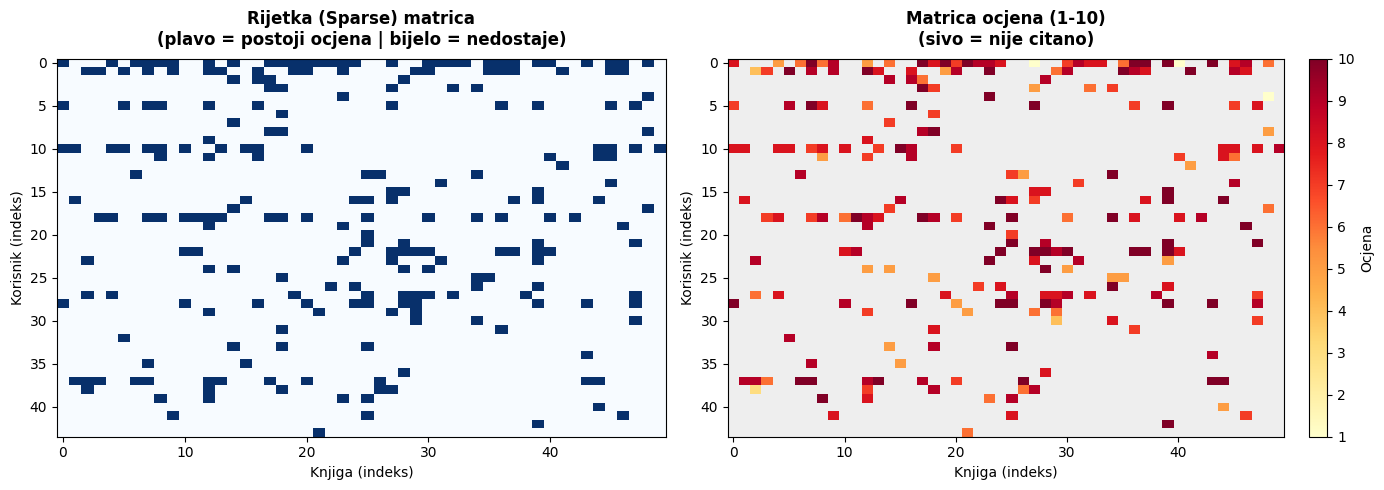

In [ ]:
sparse_mat = csr_matrix(ocjene)

print('=== Sparse matrica (CSR format) ===')
print(f'Oblik               : {sparse_mat.shape}')
print(f'Nenultih elemenata  : {sparse_mat.nnz}')
print(f'Gustoca             : {sparse_mat.nnz / (sparse_mat.shape[0] * sparse_mat.shape[1]) * 100:.1f}%')
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.imshow((ocjene > 0).astype(int), cmap='Blues', aspect='auto', interpolation='nearest')
ax1.set_title('Rijetka (Sparse) matrica\n(plavo = postoji ocjena | bijelo = nedostaje)',
              fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Knjiga (indeks)'); ax1.set_ylabel('Korisnik (indeks)')

ax2 = axes[1]
masked = np.ma.masked_where(ocjene == 0, ocjene)
cmap = plt.cm.YlOrRd.copy(); cmap.set_bad('#eeeeee')
im = ax2.imshow(masked, cmap=cmap, aspect='auto', vmin=1, vmax=10)
ax2.set_title('Matrica ocjena (1-10)\n(sivo = nije citano)',
              fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Knjiga (indeks)'); ax2.set_ylabel('Korisnik (indeks)')
plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04).set_label('Ocjena')

plt.tight_layout()
plt.show()


## NMF Faktorizacija

**NMF (Non-negative Matrix Factorization)** dekomponiše matricu ocjena $R$ na:

$$R \approx W \cdot H$$

- $W$ — matrica korisničkih latentnih preferencija
- $H$ — matrica latentnih karakteristika knjiga
- $k$ — broj latentnih faktora (skriveni stilovi čitanja)


In [ ]:
k = 5

nmf = NMF(n_components=k, init='nndsvda', max_iter=500, random_state=42)
W = nmf.fit_transform(ocjene)
H = nmf.components_

R_hat = np.clip(np.dot(W, H), 1.0, 10.0)

print('=== NMF faktorizacija zavrsena ===')
print(f'Latentnih faktora (k)   : {k}')
print(f'Broj iteracija          : {nmf.n_iter_}')
print(f'Greska rekonstrukcije   : {nmf.reconstruction_err_:.4f}')
print(f'Oblik W (korisnici x k) : {W.shape}')
print(f'Oblik H (k x knjige)    : {H.shape}')


=== NMF faktorizacija zavrsena ===
Latentnih faktora (k)   : 5
Broj iteracija          : 24
Greska rekonstrukcije   : 82.7850
Oblik W (korisnici x k) : (44, 5)
Oblik H (k x knjige)    : (5, 50)


## Rekonstruisana matrica

Množenjem $W \cdot H$ dobijamo **predviđene ocjene** za sve parove korisnik–knjiga,  
uključujući i ona mjesta koja su bila prazna. Upravo ta popunjena mjesta su naše **preporuke**.


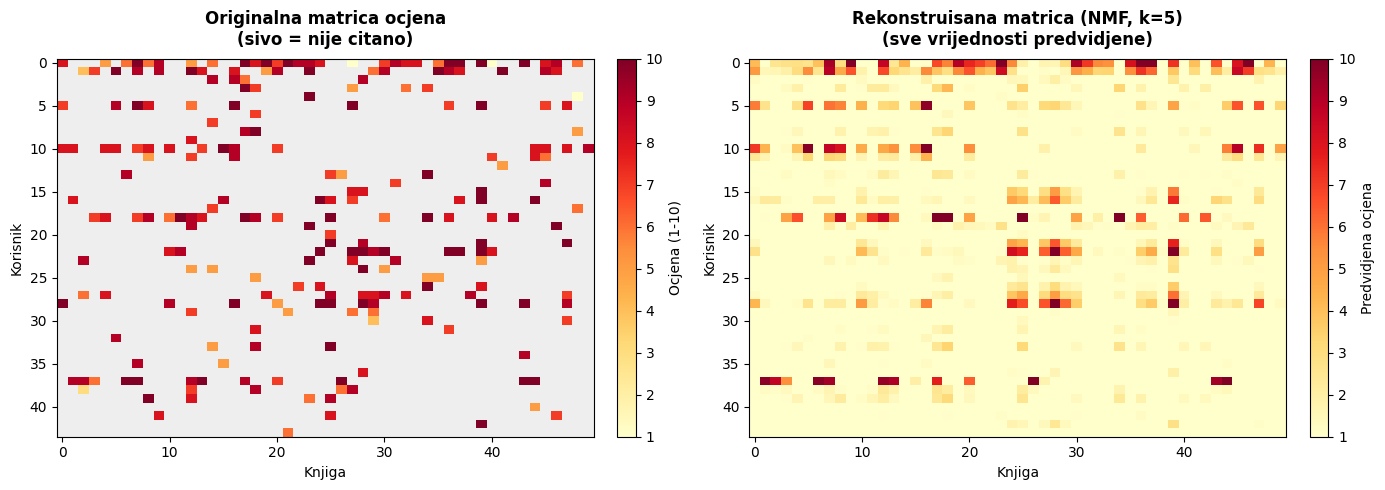

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
masked_orig = np.ma.masked_where(ocjene == 0, ocjene)
cmap1 = plt.cm.YlOrRd.copy(); cmap1.set_bad('#eeeeee')
im1 = ax1.imshow(masked_orig, cmap=cmap1, aspect='auto', vmin=1, vmax=10)
ax1.set_title('Originalna matrica ocjena\n(sivo = nije citano)',
              fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Knjiga'); ax1.set_ylabel('Korisnik')
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04).set_label('Ocjena (1-10)')

ax2 = axes[1]
sub = R_hat
im2 = ax2.imshow(sub, cmap='YlOrRd', aspect='auto', vmin=sub.min(), vmax=sub.max())
ax2.set_title(f'Rekonstruisana matrica (NMF, k={k})\n(sve vrijednosti predvidjene)',
              fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Knjiga'); ax2.set_ylabel('Korisnik')
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04).set_label('Predvidjena ocjena')

plt.tight_layout()
plt.show()


## Preporuke

Na osnovu rekonstruisane matrice generišemo top-3 preporuke za prvih 5 korisnika —  
biramo knjige koje korisnik **nije čitao**, a kojima model predviđa **najveće ocjene**.


In [ ]:
isbn_lista  = list(matrica_df.columns)
info_knjige = df_books.drop_duplicates('isbn').set_index('isbn')[['title','author']].to_dict('index')
korisnici   = list(matrica_df.index)

print('=' * 65)
print('  TOP-3 PREPORUKE ZA PRVIH 5 KORISNIKA')
print('=' * 65)

for i in range(min(5, len(korisnici))):
    negledano = np.where(ocjene[i] == 0)[0]
    if len(negledano) == 0:
        print(f'\nKorisnik {korisnici[i]}: procitao/la sve knjige iz podskupa!')
        continue
    top3 = sorted(negledano, key=lambda j: R_hat[i, j], reverse=True)[:3]
    print(f'\nKorisnik {korisnici[i]}:')
    for rang, j in enumerate(top3, 1):
        naziv = info_knjige.get(isbn_lista[j], {}).get('title', isbn_lista[j])[:45]
        print(f'  {rang}. {naziv:<47} -> predvidjena ocjena: {R_hat[i, j]:.2f}')

print('\n' + '=' * 65)


  TOP-3 PREPORUKE ZA PRVIH 5 KORISNIKA

Korisnik 11676:
  1. She's Come Undone (Oprah's Book Club)           -> predvidjena ocjena: 3.97
  2. The Pelican Brief                               -> predvidjena ocjena: 2.94
  3. Little Altars Everywhere: A Novel               -> predvidjena ocjena: 2.74

Korisnik 16795:
  1. The Divine Secrets of the Ya-Ya Sisterhood: A   -> predvidjena ocjena: 5.11
  2. The Nanny Diaries: A Novel                      -> predvidjena ocjena: 4.66
  3. The Testament                                   -> predvidjena ocjena: 4.45

Korisnik 23872:
  1. Harry Potter and the Sorcerer's Stone (Harry    -> predvidjena ocjena: 2.46
  2. The Joy Luck Club                               -> predvidjena ocjena: 1.75
  3. Harry Potter and the Chamber of Secrets (Book   -> predvidjena ocjena: 1.48

Korisnik 23902:
  1. Harry Potter and the Order of the Phoenix (Bo   -> predvidjena ocjena: 3.50
  2. The Lovely Bones: A Novel                       -> predvidjena ocjena: 2.26
  

## Analiza rezultata

Na osnovu poređenja originalne i rekonstruisane matrice zaključujemo sljedeće:

- **Preciznost:** Postojeće ocjene su gotovo identično rekonstruisane — model je uspješno naučio poznate profile korisnika.
- **Popunjavanje praznina:** Na mjestima gdje korisnik nije dao ocjenu, model predviđa vrijednosti na osnovu sličnosti s drugim korisnicima (**kolaborativno filtriranje**).
- **Latentni faktori:** Svaki od $k$ faktora odgovara nekoj skrivenoj kategoriji čitalačkih preferencija (triler, romantika, klasična literatura...) — bez eksplicitnih žanrovskih labela.
- **Zaključak:** NMF faktorizacija je uspješno popunila praznine u matrici koristeći skrivene sličnosti između korisnika i knjiga, čime je omogućeno generisanje personalnih preporuka.
